# Analyzing Results

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:
def get_runs(name):
    df = pd.read_csv(f"results/g2000tr3v2/{name}.csv")

    run0 = df[df["run"] == 0].reset_index()
    run1 = df[df["run"] == 1].reset_index()
    run2 = df[df["run"] == 2].reset_index()

    return run0, run1, run2

def plot_frequencies(df, title):
    plt.plot(df["f_L"], label="L frequency")
    plt.plot(df["f_F"], label="F frequency")
    plt.plot(df["f_B"], label="B frequency")
    plt.plot(df["f_C"], label="C frequency")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Frequency")
    plt.title(title)

    plt.show()

def plot_env_frequencies(name):
    run0, run1, run2 = get_runs(name)

    avg_run = pd.DataFrame()
    avg_run["f_L"] = pd.concat([run0["f_L"], run1["f_L"], run2["f_L"]], axis=1).mean(axis=1)
    avg_run["f_F"] = pd.concat([run0["f_F"], run1["f_F"], run2["f_F"]], axis=1).mean(axis=1)
    avg_run["f_B"] = pd.concat([run0["f_B"], run1["f_B"], run2["f_B"]], axis=1).mean(axis=1)
    avg_run["f_C"] = pd.concat([run0["f_C"], run1["f_C"], run2["f_C"]], axis=1).mean(axis=1)

    plot_frequencies(avg_run, f"Environment {name}, Mean Positional Frequencies")

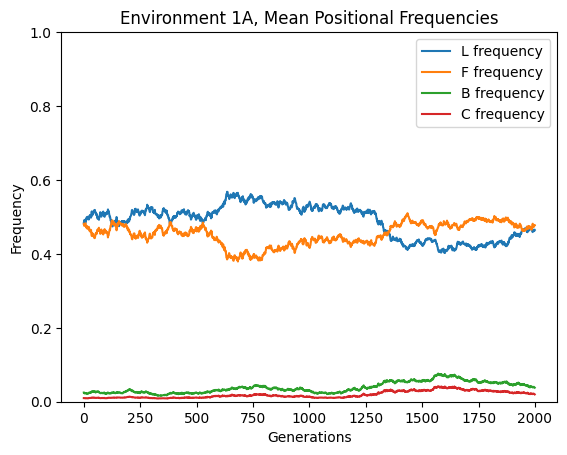

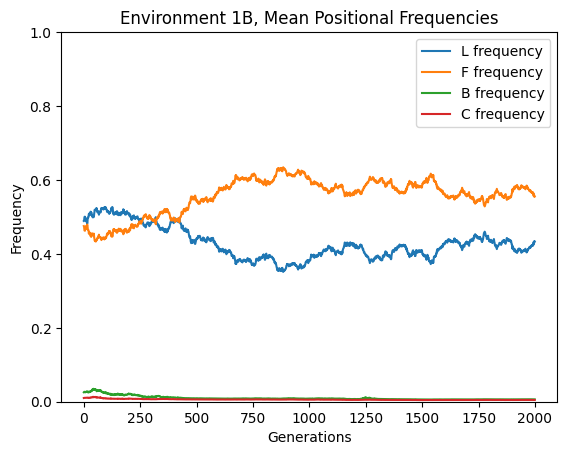

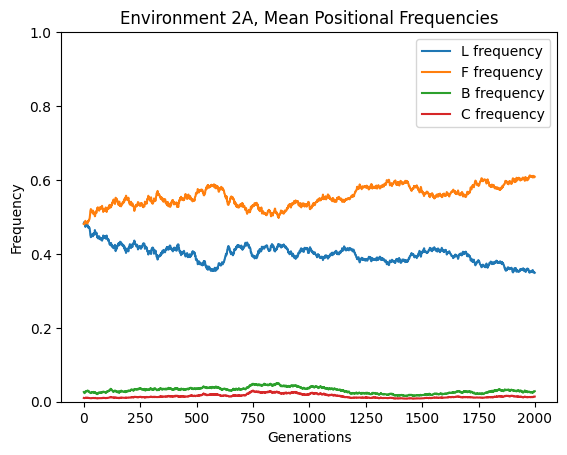

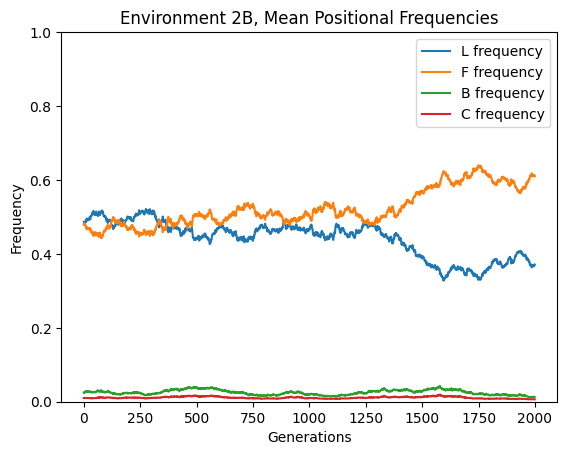

In [18]:
plot_env_frequencies("1A")
plot_env_frequencies("1B")
plot_env_frequencies("2A")
plot_env_frequencies("2B")

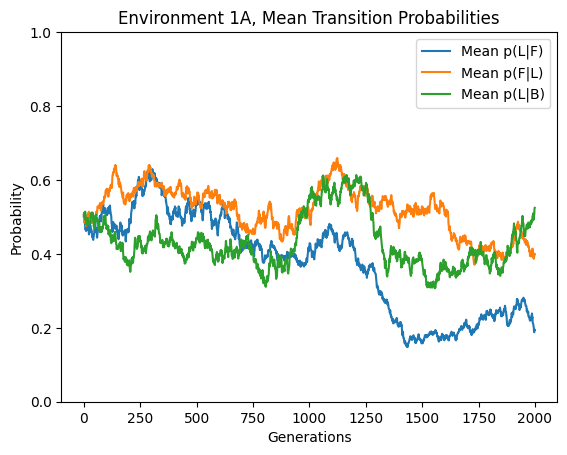

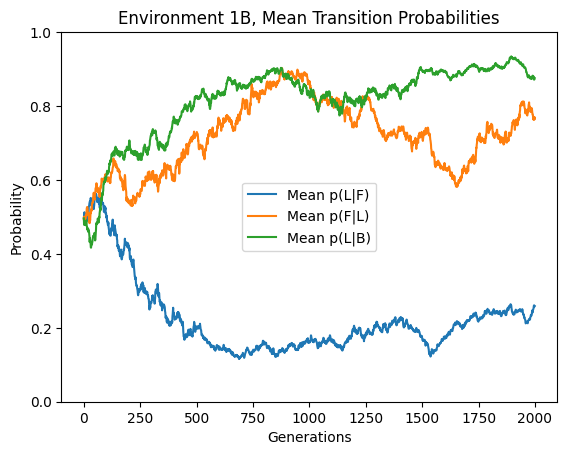

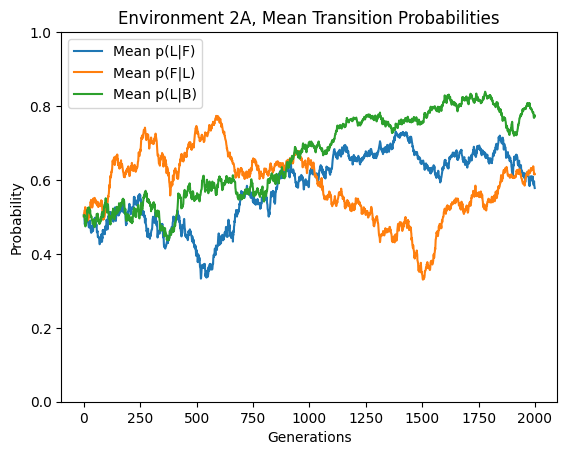

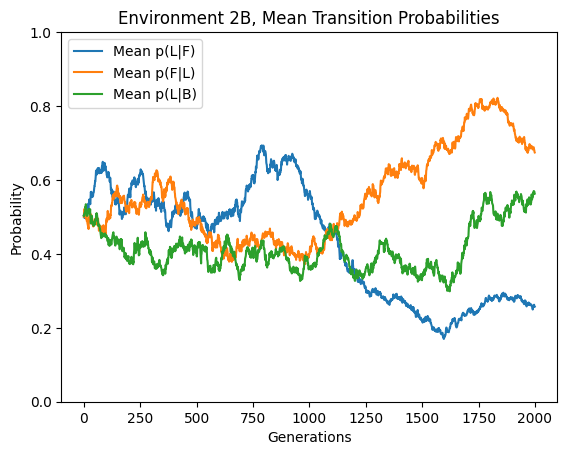

In [19]:
def plot_strategies(df, title):
    plt.plot(df["mean_p_L_given_F"], label="Mean p(L|F)")
    plt.plot(df["mean_p_F_given_L"], label="Mean p(F|L)")
    plt.plot(df["mean_p_L_given_B"], label="Mean p(L|B)")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Probability")
    plt.title(title)

    plt.show()

def plot_env_strategies(name):
    run0, run1, run2 = get_runs(name)

    avg_run = pd.DataFrame()
    avg_run["mean_p_L_given_F"] = pd.concat([run0["mean_p_L_given_F"], run1["mean_p_L_given_F"], run2["mean_p_L_given_F"]], axis=1).mean(axis=1)
    avg_run["mean_p_F_given_L"] = pd.concat([run0["mean_p_F_given_L"], run1["mean_p_F_given_L"], run2["mean_p_F_given_L"]], axis=1).mean(axis=1)
    avg_run["mean_p_L_given_B"] = pd.concat([run0["mean_p_L_given_B"], run1["mean_p_L_given_B"], run2["mean_p_L_given_B"]], axis=1).mean(axis=1)

    plot_strategies(run0, f"Environment {name}, Mean Transition Probabilities")

plot_env_strategies("1A")
plot_env_strategies("1B")
plot_env_strategies("2A")
plot_env_strategies("2B")

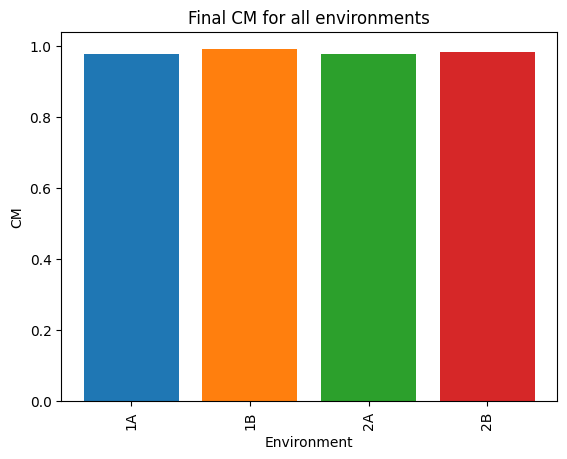

In [20]:
def plot_env_cm(names):

    for name in names:
        run0, run1, run2 = get_runs(name)
        CM = pd.concat([run0["CM"], run1["CM"], run2["CM"]], axis=1).mean(axis=1)
        plt.bar(f"{name}", CM[:-1], label=f"Env {name} CM")

    # plt.legend()
    plt.xticks(rotation=90)
    plt.xlabel("Environment")
    plt.ylabel("CM")
    plt.title("Final CM for all environments")

    plt.show()

plot_env_cm(["1A", "1B", "2A", "2B"])